In [1]:
import pandas as pd
train = pd.read_csv("../data/processed_data/training_processed.csv")
test  = pd.read_csv("../data/processed_data/test_processed.csv")
train.info()
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48775 entries, 0 to 48774
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   bed                          48775 non-null  float64
 1   bath                         48775 non-null  float64
 2   acre_lot                     48775 non-null  float64
 3   house_size                   48775 non-null  float64
 4   latitude                     48775 non-null  float64
 5   longitude                    48775 non-null  float64
 6   min_distance_to_tj           48775 non-null  float64
 7   nearest_tj_lat               48775 non-null  float64
 8   nearest_tj_lon               48775 non-null  float64
 9   lat_diff_to_tj               48775 non-null  float64
 10  lon_diff_to_tj               48775 non-null  float64
 11  state_California             48775 non-null  float64
 12  state_Florida                48775 non-null  float64
 13  state_New York  

In [2]:
import pandas as pd
df = pd.concat([train, test], ignore_index=True)
print(df.shape)


(60969, 33)


In [6]:

controls = ['bed','bath','acre_lot','house_size',
            'state_California','state_Florida',
            'state_New York','state_Texas','state_Washington']


In [8]:

import statsmodels.api as sm


# Define a threshold for "near" Trader Joe's, e.g., 5 miles
df["is_near_trader_joes"] = (df["min_distance_to_tj"] <= 5).astype(int)

X = df[['is_near_trader_joes'] + controls]
X = sm.add_constant(X)
y = df['price']
ols_presence = sm.OLS(y, X).fit()
print(ols_presence.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     4332.
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:52:08   Log-Likelihood:            -8.5939e+05
No. Observations:               60969   AIC:                         1.719e+06
Df Residuals:                   60959   BIC:                         1.719e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.254e+05   3

In [9]:

X = df[['min_distance_to_tj'] + controls]
X = sm.add_constant(X)
y = df['price']
ols_distance = sm.OLS(y, X).fit()
print(ols_distance.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     4225.
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:52:21   Log-Likelihood:            -8.5968e+05
No. Observations:               60969   AIC:                         1.719e+06
Df Residuals:                   60959   BIC:                         1.719e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               5.335e+05   1557

In [10]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_no_const = X.drop(columns='const')
vif = pd.DataFrame()
vif["variable"] = X_no_const.columns
vif["VIF"] = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
print(vif)



             variable       VIF
0  min_distance_to_tj  1.146504
1                 bed  1.794157
2                bath  1.866352
3            acre_lot  1.000392
4          house_size  1.820039
5    state_California  1.058474
6       state_Florida  1.244926
7      state_New York  1.071616
8         state_Texas  1.160913
9    state_Washington  1.023503


In [11]:

import numpy as np
import statsmodels.api as sm

df['log_price'] = np.log(df['price'])

X = df[['min_distance_to_tj','bed','bath','acre_lot','house_size',
        'state_California','state_Florida','state_New York','state_Texas','state_Washington']]
X = sm.add_constant(X)
y = df['log_price']
ols_log = sm.OLS(y, X).fit()
print(ols_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     5114.
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:53:06   Log-Likelihood:                -44990.
No. Observations:               60969   AIC:                         9.000e+04
Df Residuals:                   60959   BIC:                         9.009e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.9918      0

In [12]:

ols_log_robust = ols_log.get_robustcov_results()
print(ols_log_robust.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                 4.836e+06
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:53:18   Log-Likelihood:                -44990.
No. Observations:               60969   AIC:                         9.000e+04
Df Residuals:                   60959   BIC:                         9.009e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.9918      0

In [13]:
df["tj_x_california"] = df["min_distance_to_tj"] * df["state_California"]
X_int = df[[
    "min_distance_to_tj","tj_x_california","bed","bath","acre_lot","house_size",
    "state_California","state_Florida","state_New York","state_Texas","state_Washington"
]]
X_int = sm.add_constant(X_int)
y = df["log_price"]
ols_inter = sm.OLS(y, X_int).fit(cov_type="HC1")
print(ols_inter.summary())



                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                 4.562e+06
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        10:53:30   Log-Likelihood:                -44124.
No. Observations:               60969   AIC:                         8.827e+04
Df Residuals:                   60958   BIC:                         8.837e+04
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.9929      0

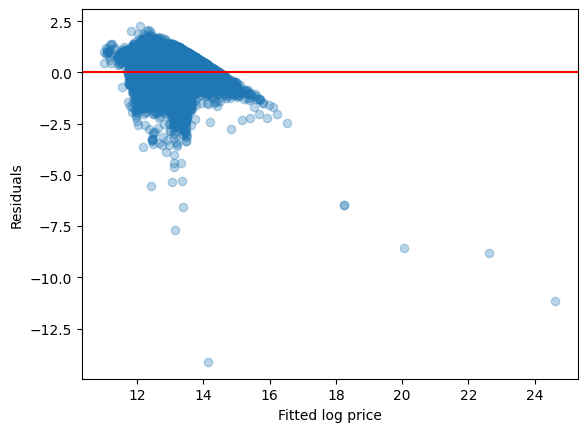

In [14]:
import matplotlib.pyplot as plt
plt.scatter(ols_log.fittedvalues, ols_log.resid, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Fitted log price")
plt.ylabel("Residuals")
plt.show()

In [15]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

feature_cols = [
    "min_distance_to_tj",
    "bed",
    "bath",
    "acre_lot",
    "house_size",
    "state_California",
    "state_Florida",
    "state_New York",
    "state_Texas",
    "state_Washington",
]
X = df[feature_cols].copy()
y = df["price"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((48775, 10), (12194, 10))

In [17]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
    ),
    "HistGB": HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_depth=None,
        max_iter=300,
        random_state=42,
    ),
    # ElasticNet scaling
    "ElasticNet": make_pipeline(
        StandardScaler(with_mean=False),
        ElasticNet(alpha=0.0001, l1_ratio=0.5, random_state=42, max_iter=10000),
    ),
}
results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)
    results.append({
        "model": name,
        "rmse_$": rmse,
        "r2": r2,
    })
    fitted[name] = {
        "model": model,
        "y_pred": y_pred,
    }
results_df = pd.DataFrame(results)
results_df


/Users/nazimmeknojiya/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.509e+15, tolerance: 8.216e+11
  model = cd_fast.enet_coordinate_descent(


,model,rmse_$,r2
0,RandomForest,217994.066488,0.714492
1,HistGB,224332.910392,0.697647
2,ElasticNet,326098.517963,0.361109


house_size            0.348487
min_distance_to_tj    0.311465
acre_lot              0.089133
bath                  0.062700
state_Texas           0.061085
state_California      0.055076
bed                   0.036377
state_New York        0.024001
state_Florida         0.007837
state_Washington      0.003840
dtype: float64


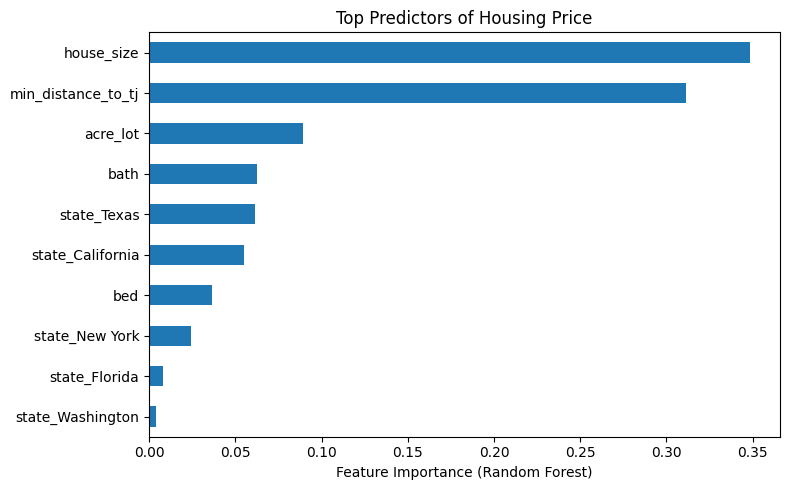

In [18]:
rf = fitted["RandomForest"]["model"]
feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(feat_importance)
feat_importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Feature Importance (Random Forest)")
plt.title("Top Predictors of Housing Price")
plt.tight_layout()
plt.show()

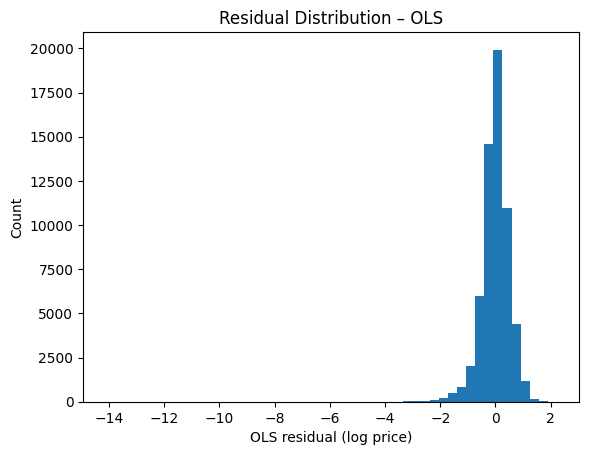

In [19]:

ols_resid = ols_inter.resid
plt.hist(ols_resid, bins=50)
plt.xlabel("OLS residual (log price)")
plt.ylabel("Count")
plt.title("Residual Distribution – OLS")
plt.show()


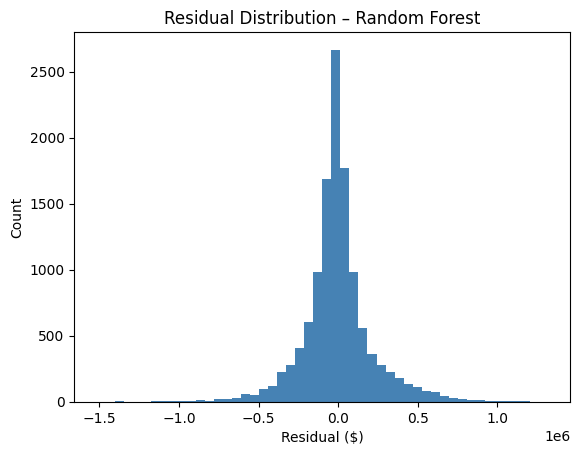

In [20]:
rf_preds = fitted["RandomForest"]["y_pred"]
resid_rf = y_test - rf_preds
plt.hist(resid_rf, bins=50, color='steelblue')
plt.xlabel("Residual ($)")
plt.ylabel("Count")
plt.title("Residual Distribution – Random Forest")
plt.show()
